# Test of Python and Jupyter Lab for USPAS Fundamentals of Accelerator Physics Class

# Basic Functionality
Make sure the necessary libraries are present.  Install any missing libraries with pip.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt     # Plotting package
import numpy as np                  # Numerical libraries
import pandas as pd                 # Pandas tables
import ipywidgets as widgets        # GUI widgets
from IPython.display import display # Display widgets

This simple numpy example should produce a sine wave from 0 to 6$\pi$

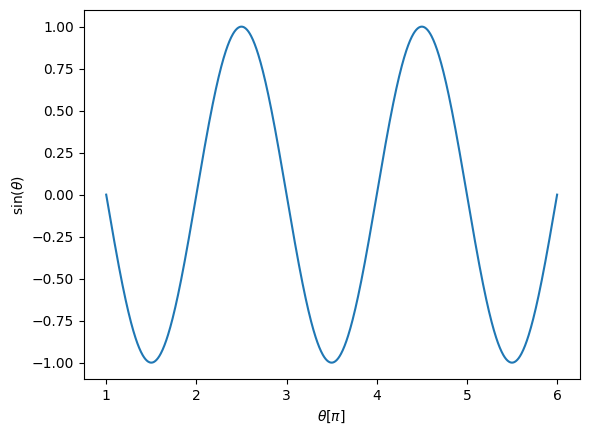

In [2]:
x = np.linspace(1,6,1000)
y = np.sin(np.pi*x)

plt.plot(x,y)
plt.xlabel(r'$\theta [\pi]$')
plt.ylabel(r'$\sin(\theta)$')
plt.show()

Now do a simmilar plot with a Panda table

This should make a cosine plot from 0 to $6\pi$

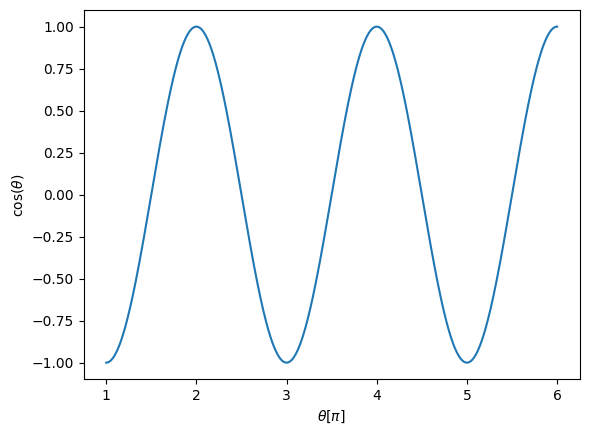

In [3]:
df = pd.DataFrame(data=x,columns=['x'])
df['y'] = np.cos(np.pi*df['x'])
plt.plot(df['x'],df['y'])
plt.xlabel(r'$\theta [\pi]$')
plt.ylabel(r'$\cos(\theta)$')
plt.show()

Example of a GUI slider widget

This should produce a persistent horizontal slide that updates the K and f values as it's operated.

In [4]:
slider = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=2.0,
    step=0.01,
    description='k'
)

output = widgets.Output()

def update(change):
    k = change["new"]
    f = 1.0 / k

    with output:
        output.clear_output(wait=True)
        print(f"k = {k:.3f}")
        print(f"f = {f:.3f} m")

slider.observe(update, names='value')

display(slider, output)

# initialize display
update({'new': slider.value})

FloatSlider(value=0.5, description='k', max=2.0, min=0.1, step=0.01)

Output()

# Xsuite test
This part can only by run under MacOS, Linux, or WSL.  It will not run under Windows.

It will read in the MADX definition of a Main Ring FODO cell and plot the $\beta$ and $\alpha$ Twiss parameters

First make sure all the libraries load.  Install any missing libraries with pip.

In [6]:
from cpymad.madx import Madx       # This allows Xsuite to read a Madx file
import numpy as np
import xtrack as xt                # Xsuite tracker
import xpart as xp                 # Xsuite particle library
import matplotlib.pyplot as plt    # Plotting utility

Converting sequence "fodo":   0%|          | 0/12 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/12 [00:00<?, ?it/s]

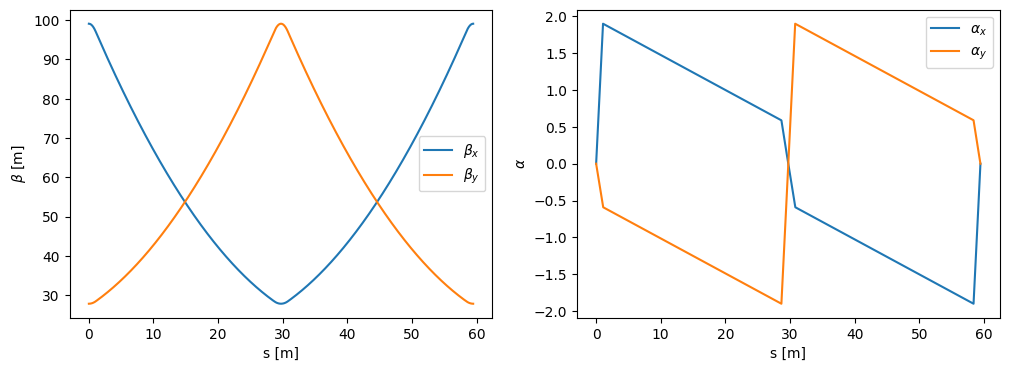

In [8]:
mad = Madx(stdout=False)  # Otherwise it will dump all the output to the screen

# This call will execute the entire file, including any resulting plots
mad.call(file="main_ring.madx")

sequence=mad.sequence['fodo']

# Convert a MADX secquence to an Xsuite line
line=xt.Line.from_madx_sequence(sequence)

# It does not remember the definition at the beginning of the MadX file, so you 
# need to explicitly import it.
line.particle_ref = xp.Particles(
    p0c=sequence.beam.pc * 1e9,
    q0=1,     # charge
    mass0=xp.PROTON_MASS_EV
)

line.build_tracker()
# By default, this will only calculate optics functions at elements and markers, so I'll slice it to make
# it continuous
s = np.linspace(0, line.get_length(), 5000)
line.cut_at_s(s)

tw = line.twiss(method='4d')  # Calculate the Twiss parameters.  With no initial conditions, it
                              # will calculate a periodic solution

# plot the beta and alpha function
plt.figure(figsize=[12,4])
plt.subplot(121)
plt.plot(tw.s,tw.betx,label=r'$\beta_x$')
plt.plot(tw.s,tw.bety,label=r'$\beta_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.legend()

plt.subplot(122)
plt.plot(tw.s,tw.alfx,label=r'$\alpha_x$')
plt.plot(tw.s,tw.alfy,label=r'$\alpha_y$')
plt.xlabel('s [m]')
plt.ylabel(r'$\alpha$')
plt.legend()


plt.show()